# Détection des Émotions avec PyCaret


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from pycaret.classification import setup, compare_models, pull

In [5]:
train = pd.read_csv("data/emotions_train.csv")
test = pd.read_csv("data/emotions_test.csv")

In [6]:
test = test.rename(columns={"content": "Text", "sentiment": "Emotion"})
train = train[["Text", "Emotion"]]
test = test[["Text", "Emotion"]]


In [7]:
combined = pd.concat([train, test], ignore_index=True)

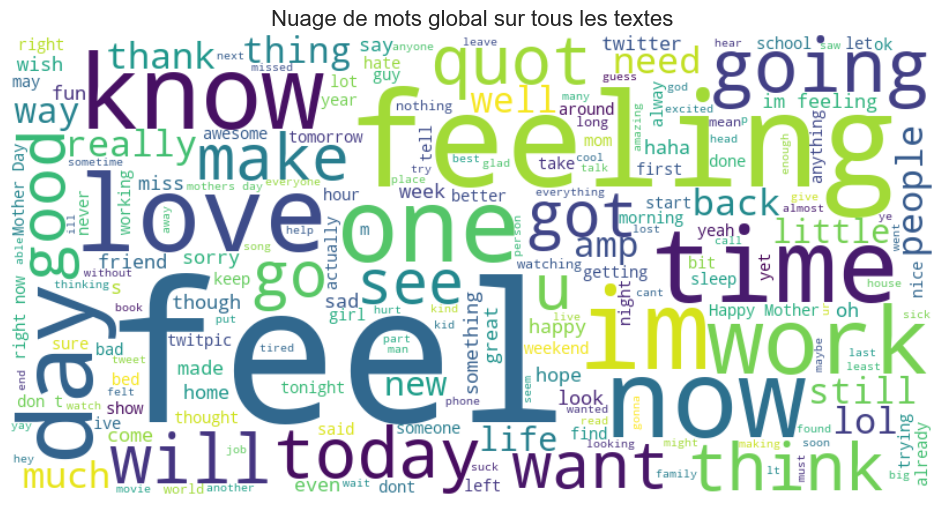

In [8]:
all_text = " ".join(combined["Text"].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Nuage de mots global sur tous les textes", fontsize=16)
plt.show()

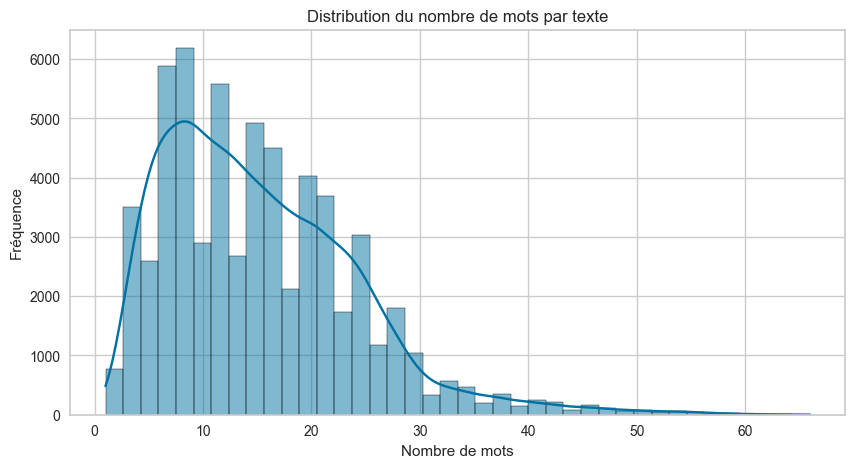

In [9]:
combined["text_length"] = combined["Text"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(combined["text_length"], bins=40, kde=True)
plt.title("Distribution du nombre de mots par texte")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.show()

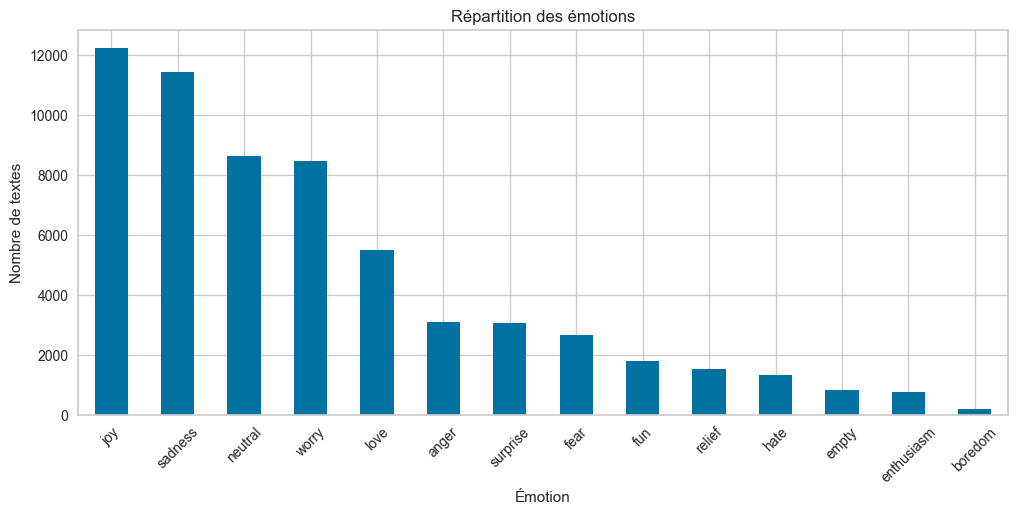

In [10]:
plt.figure(figsize=(12, 5))
combined["Emotion"].value_counts().plot(kind='bar')
plt.title("Répartition des émotions")
plt.xlabel("Émotion")
plt.ylabel("Nombre de textes")
plt.xticks(rotation=45)
plt.show()

In [ ]:
setup(
    data=combined,
    target='Emotion',
    session_id=123,
    text_features=['Text'],
    preprocess=True,
    verbose=False
)

In [ ]:
best_models = compare_models(n_select=5, sort='Accuracy')
results = pull()
print("\nTop modèles comparés :")
print(results)
